In [2]:
import  torch 
torch.cuda.get_device_name(torch.cuda.current_device()) # Tesla T4

'Tesla T4'

In [3]:
%load_ext autoreload
%autoreload 2
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *
configure_matplotlib()
SAVE_FIGURES = True
fig_path = RETROSEQ_FIGURE_DIR
from functools import partial
save_figure = partial(save_figure, dir_path=fig_path)
cpm_scl = CPM_SCL

PROJECT_ROOT: /code
CODE_DIR: /code
CODE_DIR exists: True
Python path includes CODE_DIR: True


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import scvi
import anndata
from sklearn.neighbors import NearestNeighbors

import processing, utils, plotting, heatmap, transcriptomics_analysis
import pseudoclusters, test_structures
print(f"scanpy version: {sc.__version__}")
print(f"scvi version: {scvi.__version__}")

scanpy version: 1.11.3
scvi version: 1.3.3


In [5]:
RETROSEQ_DATA_DIR

'/data/retroseq'

In [5]:
print("Loading retroseq and snRNA data...")
filename = os.path.join(RETROSEQ_DATA_DIR, 'retroseq_updated_filtered.h5ad')
adata_retro = sc.read_h5ad(filename)

# Load snRNA data for gene filtering
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")
adata_sc = sc.read_h5ad(myfilename)
adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})

# Filter genes to match snRNA data
keepgenes = np.intersect1d(list(adata_sc.var_names), list(adata_retro.var_names))
print(f"Number of shared genes: {keepgenes.shape[0]}")
adata_retro = adata_retro[:, keepgenes].copy()
adata_retro.raw = adata_retro.copy() # the raw now will preserve the not-length-normalized versions


# # length normalizations
gene_lengths = transcriptomics_analysis.gene_lengths_from_gtf(OTHERS_DIR+"/gencode.vM38.annotation.gtf.gz")
adata_retro.var["gene_length_bp"] = adata_retro.var_names.map(gene_lengths)
adata_retro.var["gene_length_bp"] = adata_retro.var["gene_length_bp"].fillna(adata_retro.var["gene_length_bp"].median())
X_foo = transcriptomics_analysis.tpm_normalize(adata_retro.X, adata_retro.var["gene_length_bp"].values)
adata_retro.X = np.around(X_foo.toarray()).astype(int)


# Check normalization of reference dataset
print(f"Reference dataset sum per cell: {np.mean(np.sum(adata_sc.layers['BN'], 1)):.4f}")

Loading retroseq and snRNA data...


/tmp/ipykernel_9729/955629651.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})


Number of shared genes: 1502
Reference dataset sum per cell: 1.0000


In [6]:
np.sum(adata_retro.X, axis = 0)<1

array([False, False, False, ..., False, False, False])

In [7]:
adata_retro.var_names[np.sum(adata_retro.X, axis = 0)<1]

Index(['1700039E22Rik', '4930527G23Rik', '4933417O13Rik', '4933433F19Rik',
       'AI507597', 'Adam25', 'Areg', 'Atp6v1e2', 'Cav3', 'Cd3d', 'Cdk19os',
       'Cxcl10', 'Cxcl9', 'Defb50', 'Fam240b', 'Foxb1', 'Gm12668', 'Gm15527',
       'Gm15962', 'Gm15987', 'Gm29010', 'Gm35963', 'Gm4128', 'Gm41311',
       'Gm43242', 'Gm43255', 'Gm47150', 'Gm50242', 'Gm9573', 'Gpr65', 'Ifi209',
       'Krtap14', 'Myhas', 'Pf4', 'Pga5', 'Sln', 'Trim69'],
      dtype='object')

frontal cortex: (173, 1502)
cerebellum: (210, 1502)
spinal cord: (184, 1502)
thalamus: (522, 1502)

 *** batcheffect by mice ID for each projection target ***

frontal cortex


/tmp/ipykernel_9729/15839697.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


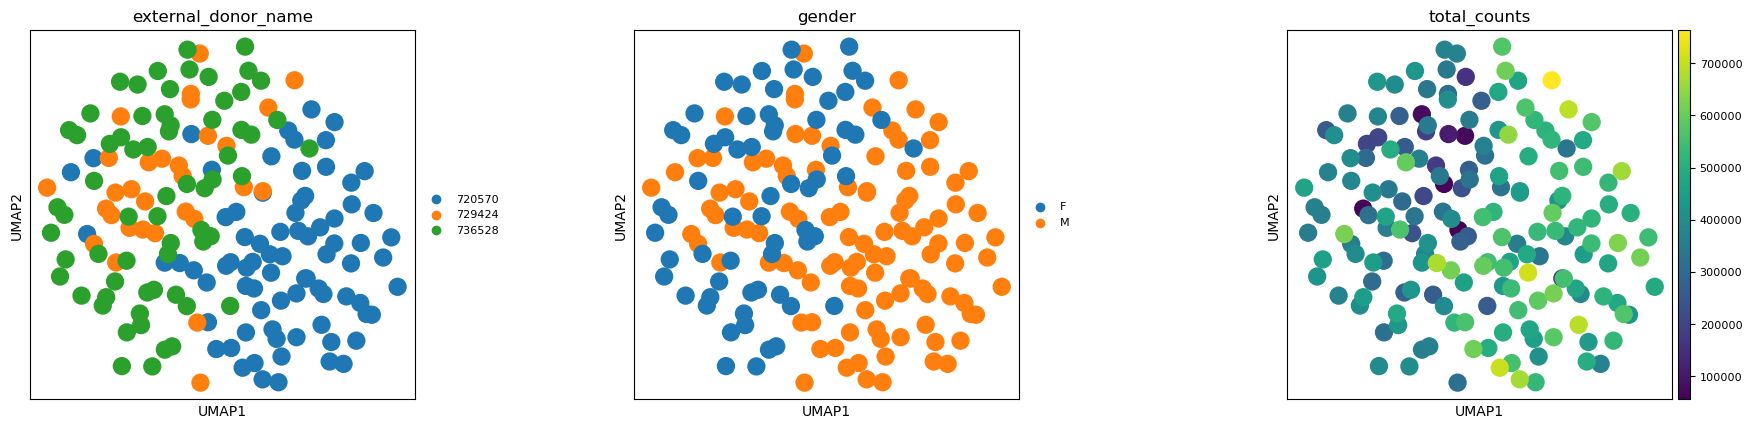


cerebellum


/tmp/ipykernel_9729/15839697.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


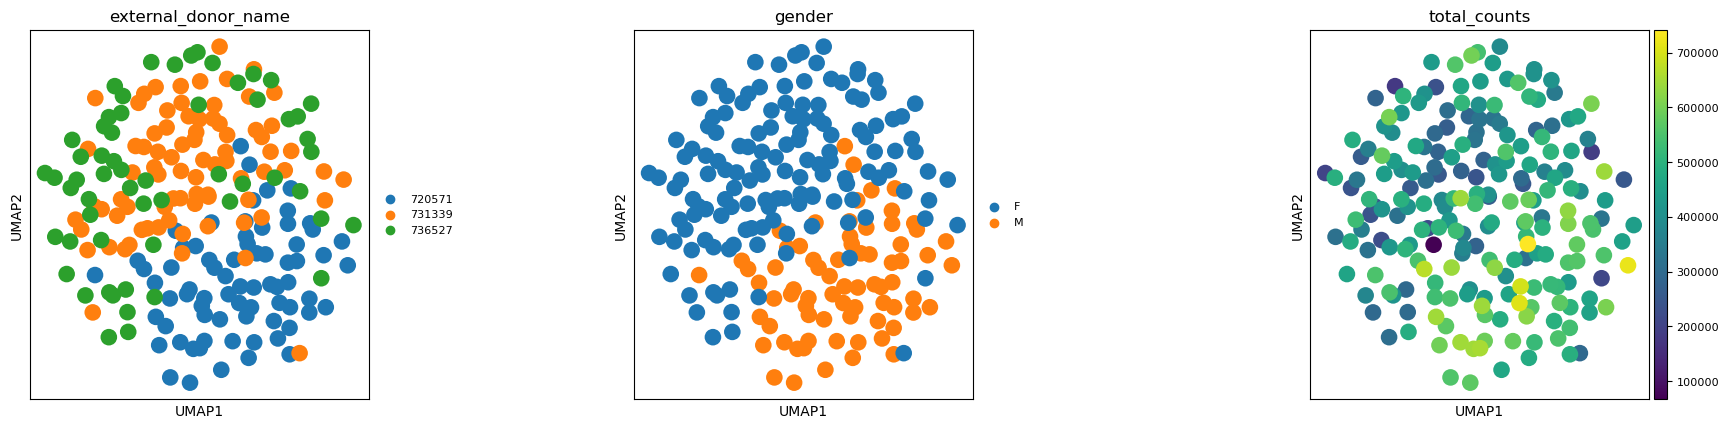


spinal cord


/tmp/ipykernel_9729/15839697.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


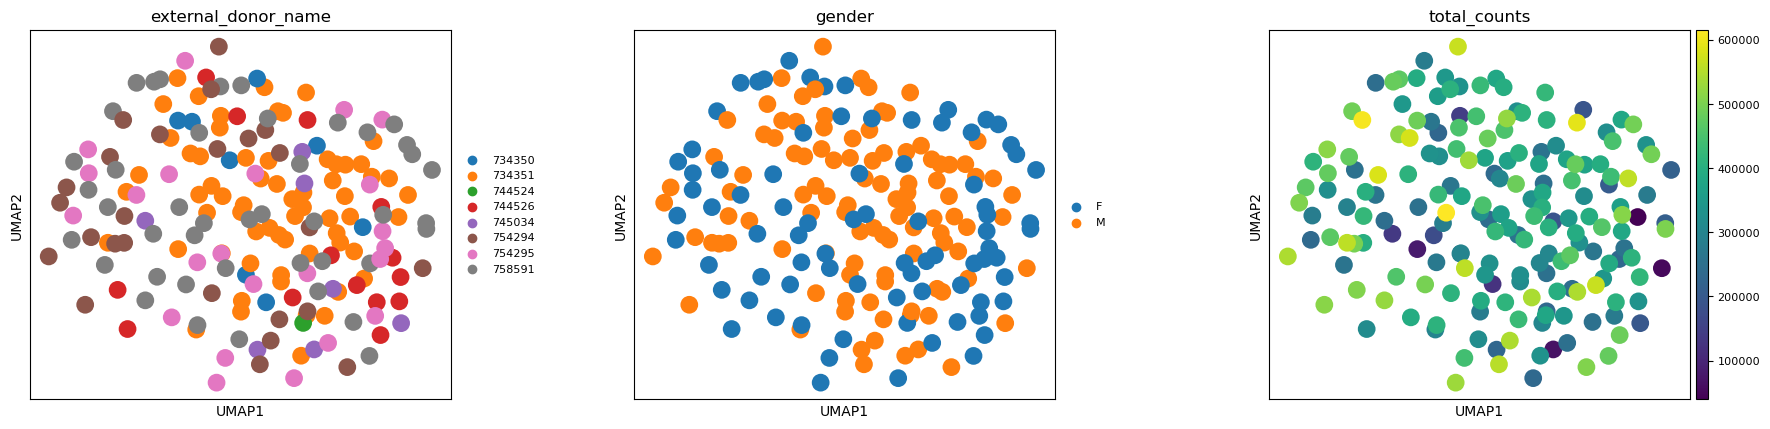


thalamus


/tmp/ipykernel_9729/15839697.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


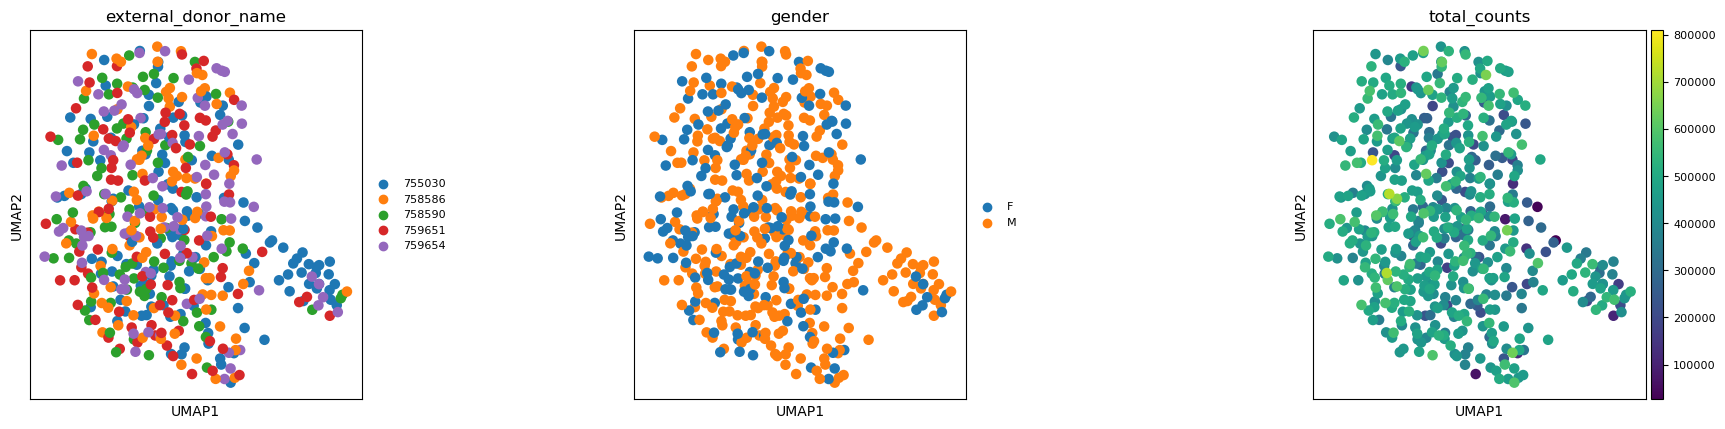


*** all the samples - check mice ID batch effect *** 


/tmp/ipykernel_9729/15839697.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


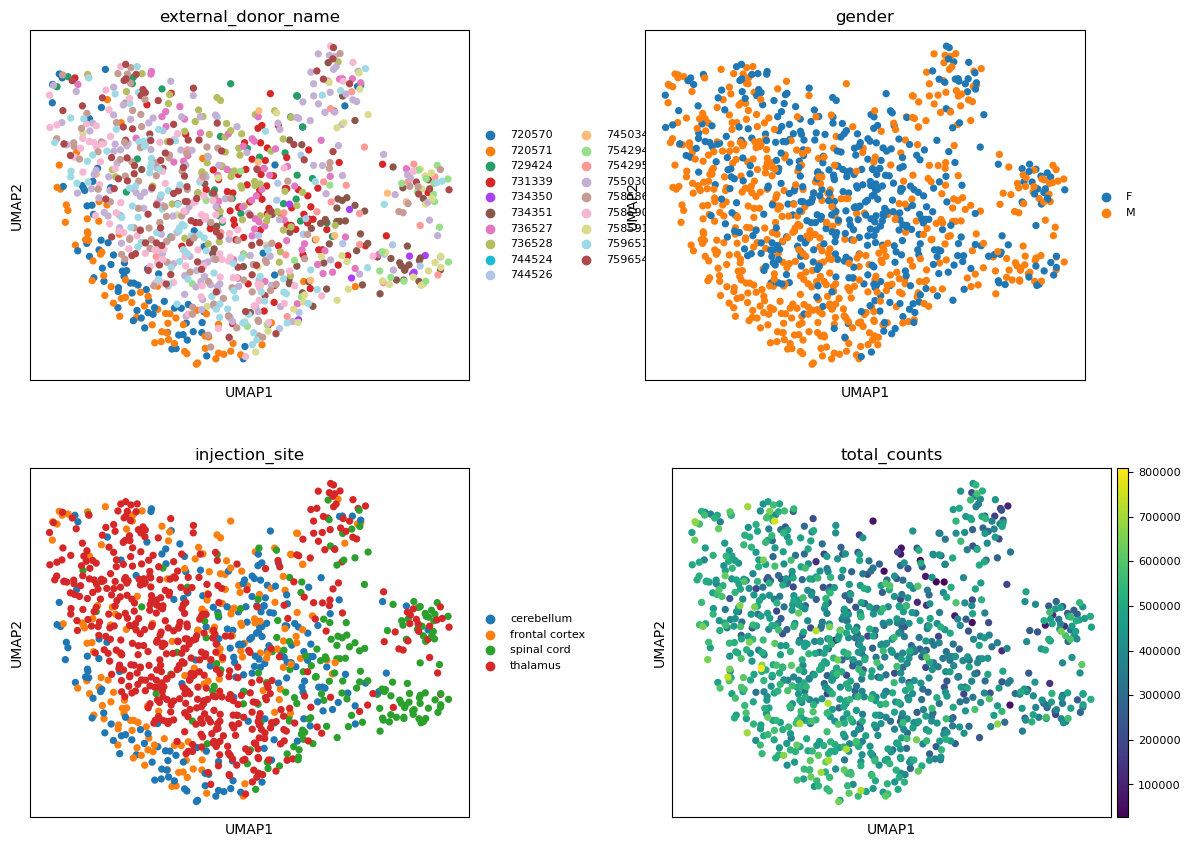


*** Random Forest evaluation (gender and mice ID as outcome) *** 
gender accuracy: 0.654 ± 0.017 (chance: 0.500)


/opt/conda/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


external_donor_name accuracy: 0.384 ± 0.025 (chance: 0.053)
injection_site accuracy: 0.551 ± 0.014 (chance: 0.250)
Saving figure to: /root/capsule/output/figures/retroseq/rf_batch_effects_raw_data.svg
Saving figure to: /root/capsule/output/figures/retroseq/rf_batch_effects_raw_data.png


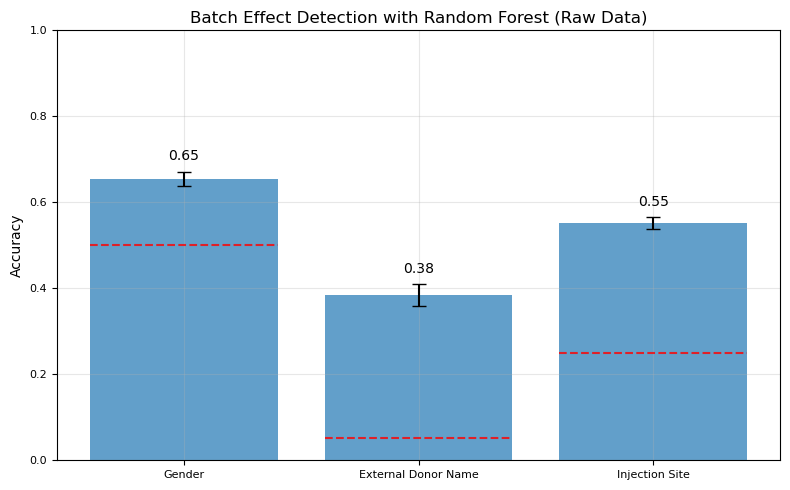

In [8]:
import batch_checking 
# Copy and modify the main function in your notebook
def run_comprehensive_batch_analysis_with_save(adata):
    """Run complete batch effect analysis pipeline with figure saving"""
    projection_subsets = batch_checking.create_projection_subsets(adata, 'injection_site')
    print("\n *** batcheffect by mice ID for each projection target ***")
    
    for group_name, adata_subset in projection_subsets.items():
        print(f"\n{group_name}")
        sc.tl.umap(adata_subset, random_state=210)
        ax = sc.pl.umap(adata_subset, color=["external_donor_name", "gender", 'total_counts'], 
                       ncols=3, show=False)
        for a in ax:
            a.set_aspect('equal')
        plt.tight_layout()
        plt.show()

    print("\n*** all the samples - check mice ID batch effect *** ")
    adata_processed = batch_checking.preprocess_full_dataset(adata)
    ax = sc.pl.umap(adata_processed, color=["external_donor_name", "gender", 'injection_site', 'total_counts'], 
                    ncols=2, show=False)
    for a in ax:
        a.set_aspect('equal')
    plt.tight_layout()
    plt.show()

    print("\n*** Random Forest evaluation (gender and mice ID as outcome) *** ")
    rf_results = batch_checking.evaluate_batch_effects_rf(adata)
    batch_checking.plot_rf_results(rf_results, " (Raw Data)")
    save_figure('rf_batch_effects_raw_data')


batch_results = run_comprehensive_batch_analysis_with_save(adata_retro)


In [9]:
orig_proj_target = list( adata_retro.obs['injection_site'])

mapping = {
    cat: cat.title()
    for cat in adata_retro.obs['injection_site'].cat.categories}

adata_retro.obs['injection_site'] = (
    adata_retro.obs['injection_site']
    .cat.rename_categories(mapping))

In [10]:
scvi.settings.seed = 1
scvi.model.SCVI.setup_anndata(
    adata_retro, 
    batch_key='external_donor_name', 
)
model = scvi.model.SCVI(adata_retro, n_layers=1, n_latent=4, gene_likelihood="zinb")
model.train()


print("SCVI model training complete")
SCVI_LATENT_KEY = "X_scVI"
adata_retro.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

Seed set to 1
/opt/conda/lib/python3.12/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 8 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/opt/conda/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


SCVI model training complete


Creating UMAP visualization...


/tmp/ipykernel_9729/3325840655.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


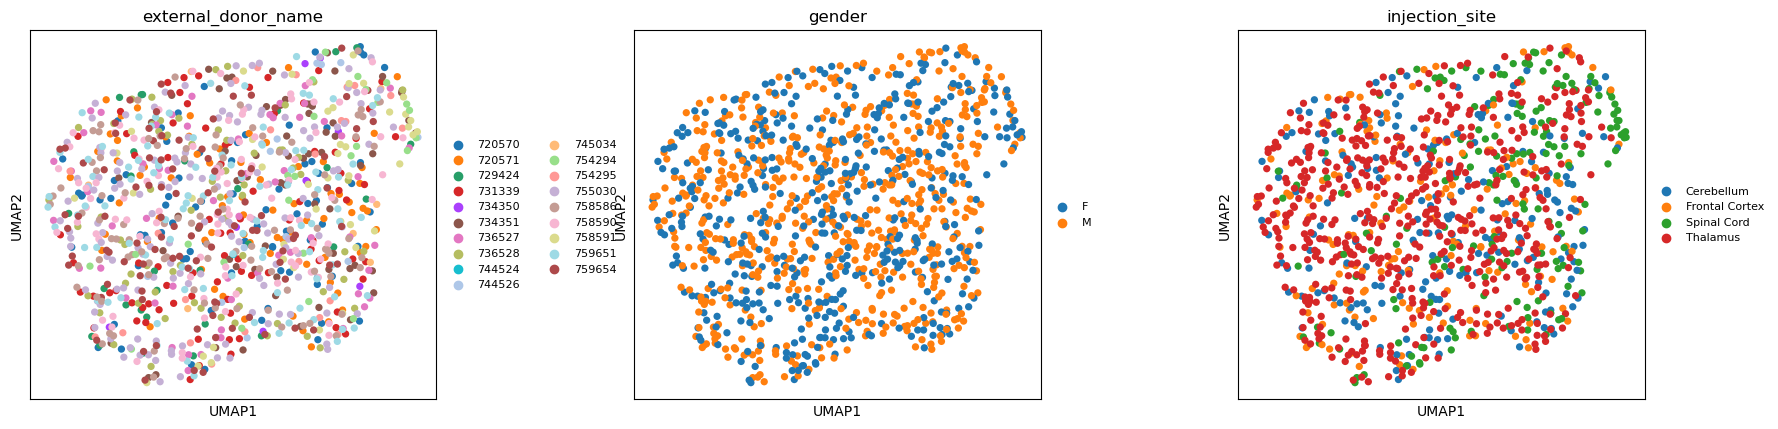

In [11]:
# UMAP Visualization
print("Creating UMAP visualization...")

# Compute neighbors and UMAP embedding
sc.pp.neighbors(adata_retro, use_rep=SCVI_LATENT_KEY)#, n_neighbors=50)
sc.tl.umap(adata_retro, random_state=210)

# Plot UMAP with metadata
ax = sc.pl.umap(adata_retro, color=["external_donor_name", "gender", 'injection_site'], 
           ncols=3, show=False)
for a in ax:
    a.set_aspect('equal')
plt.tight_layout()

In [12]:
# Clean projection target Categories
# Define categories and handle thalamus
cate_list = ["Frontal Cortex", 'Cerebellum', "Spinal Cord", 'Thalamus']
adata_retro.obs['injection_site'].replace('thalamus', np.nan, inplace=True)
adata_retro.obs['injection_site'] = adata_retro.obs['injection_site'].astype('category')
adata_retro.obs['injection_site'] = adata_retro.obs['injection_site'].cat.remove_unused_categories()
adata_retro.uns.pop('injection_site_colors', None)
adata_retro.obs["injection_site"] = pd.Categorical(
    adata_retro.obs["injection_site"],
    categories=cate_list[:-1],
    ordered=True
)
print("projection target:")
print(adata_retro.obs['injection_site'].value_counts())

# Create color dictionary
cm = plt.cm.get_cmap('tab10')
default_colors = list(cm.colors)
col_list = default_colors[:3]
col_dict = {cate_list[i]: col_list[i] for i in range(len(cate_list))[:3]}
col_dict['others'] = 'white'

projection target:
injection_site
Cerebellum        210
Spinal Cord       184
Frontal Cortex    173
Name: count, dtype: int64


/tmp/ipykernel_9729/3789219233.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata_retro.obs['injection_site'].replace('thalamus', np.nan, inplace=True)
/tmp/ipykernel_9729/3789219233.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab10')


In [13]:
col_dict

{'Frontal Cortex': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765),
 'Cerebellum': (1.0, 0.4980392156862745, 0.054901960784313725),
 'Spinal Cord': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'others': 'white'}

/tmp/ipykernel_9729/1834731600.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure to: /root/capsule/output/figures/retroseq/BN_results.svg
Saving figure to: /root/capsule/output/figures/retroseq/BN_results.png


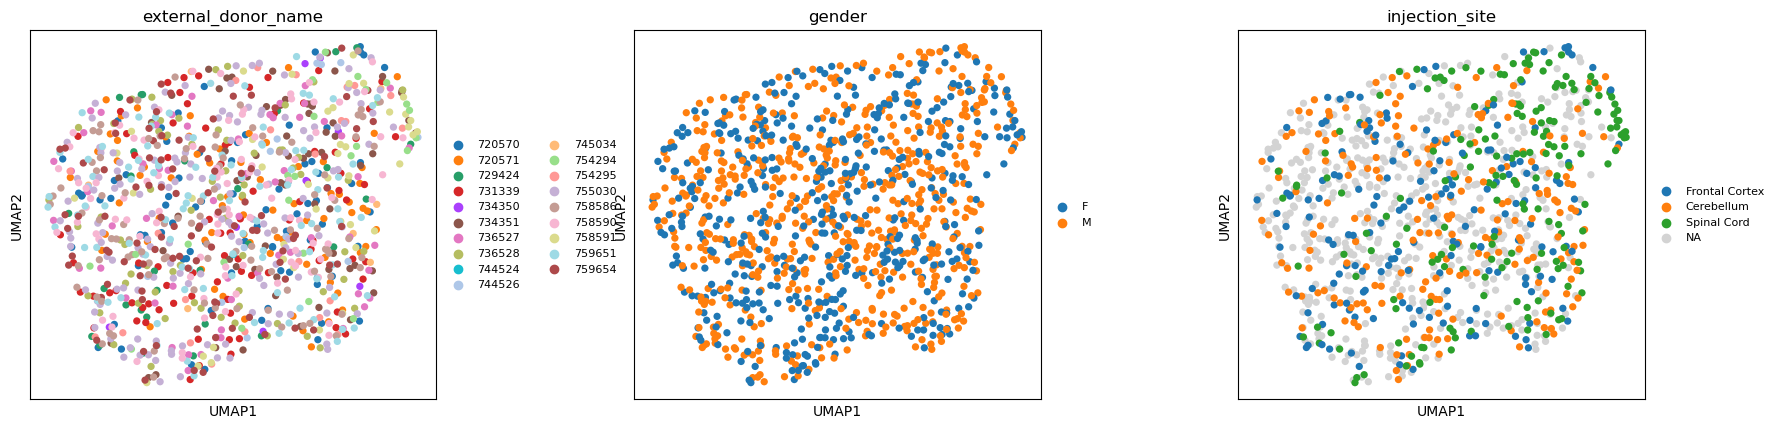

In [14]:
# Plot UMAP with metadata
ax = sc.pl.umap(adata_retro, color=["external_donor_name", "gender", 'injection_site'], 
           ncols=3, show=False)
for a in ax:
    a.set_aspect('equal')
plt.tight_layout()
save_figure("BN_results")

Saving figure to: /root/capsule/output/figures/retroseq/injection_site_umap.svg
Saving figure to: /root/capsule/output/figures/retroseq/injection_site_umap.png


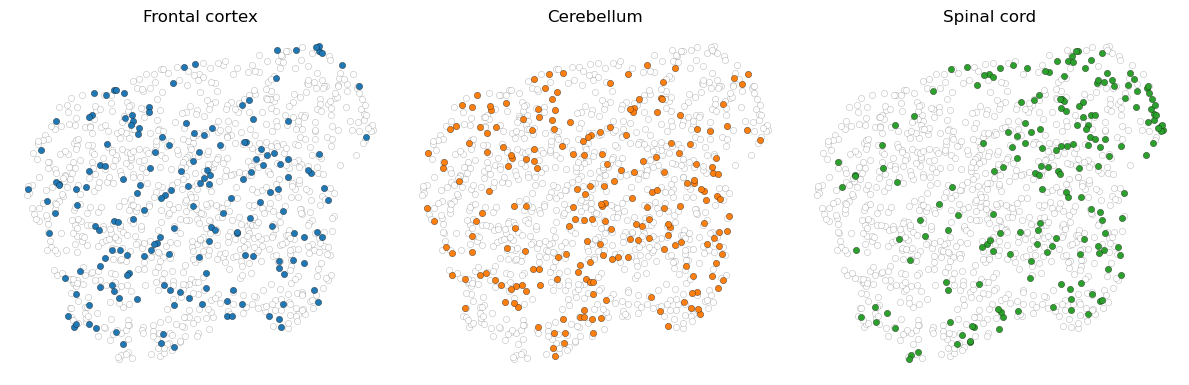

In [15]:
# projection target Visualization on UMAP
umap_coords = adata_retro.obsm['X_umap']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for m, k in enumerate(cate_list[:-1]):
    ax = axes[m]
    # Plot all cells in white
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], 
               color='white', s=20, alpha=1, label='_nolegend_',
               edgecolor='k', linewidth=.1)
    mask = adata_retro.obs['injection_site'] == k
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], 
               color=col_dict[k], s=20, alpha=1, label=k,
               edgecolor='k', linewidth=.2)
    ax.set_aspect('equal')
    ax.set_title(k.capitalize())
    ax.set_xticks([]);ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.95])
save_figure("injection_site_umap")

In [16]:
adata_retro.layers

Layers with keys: 

In [17]:
# Add Normalized Layer and Save
print("Adding normalized layer (BN) and saving data...")
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
adata_retro.layers["BN"] = model.get_normalized_expression(adata_retro, 
                                                           transform_batch=all_batches, library_size= 1)

savefilename = RETROSEQ_DATA_DIR+"/retro_BN_d4_1500genes.h5ad"
adata_retro.write(savefilename)
print(f"Data saved to: {savefilename}")

adata_retro_BN = adata_retro.copy()
adata_retro_BN.X = adata_retro.layers['BN'].copy()
print("Created copy with BN as main layer")


# Add log(CPM) layer to adata_retro_BN
adata_retro_BN.layers["CPM"] = adata_retro_BN.X.copy()
sc.pp.normalize_total(adata_retro_BN, target_sum=1e6, layer="CPM")
adata_retro_BN.layers["log(CPM)"] = adata_retro_BN.layers["CPM"].copy()
sc.pp.log1p(adata_retro_BN, layer="log(CPM)")

Adding normalized layer (BN) and saving data...


Data saved to: /root/capsule/data/retroseq/retro_BN_d4_1500genes.h5ad
Created copy with BN as main layer


# run pca for checking

### this is how it was done for 10x data

In [18]:
np.allclose(np.sum(adata_retro_BN.X,1),1)  # make sure library size is 1 now 

True

/tmp/ipykernel_9729/3766284792.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


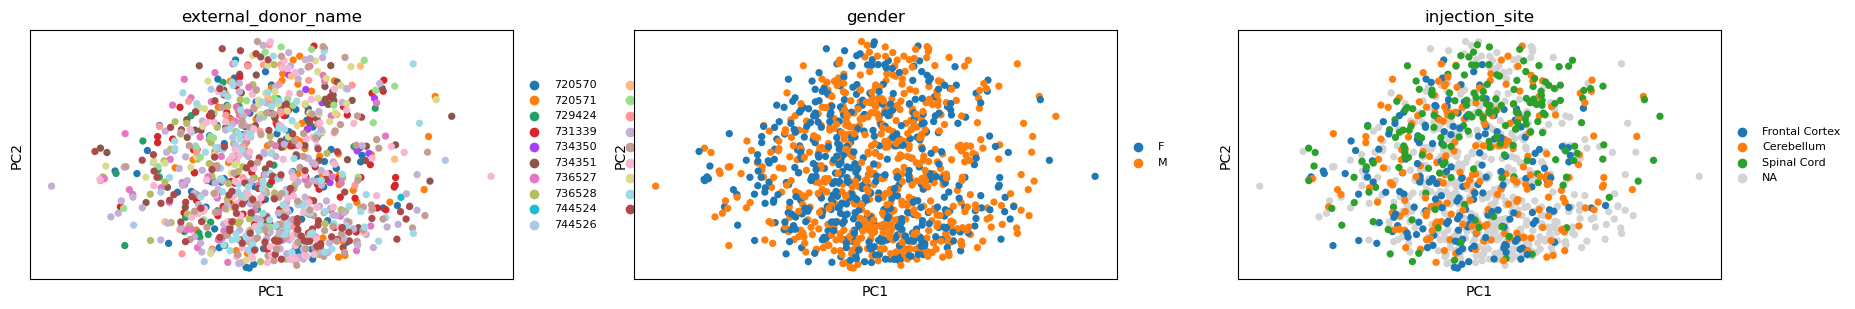

In [19]:
adata_pca = adata_retro_BN.copy()  # so its library size of 1

sc.pp.scale(adata_pca, zero_center=True, max_value=10)
sc.tl.pca(adata_pca, n_comps=50, svd_solver='arpack')

ax = sc.pl.pca(adata_pca,
    color=["external_donor_name", "gender", "injection_site"],ncols=3,show=False)
for a in ax:
    a.set_aspect("equal")
plt.tight_layout()

Saving figure to: /root/capsule/output/figures/retroseq/injection_site_pca.svg
Saving figure to: /root/capsule/output/figures/retroseq/injection_site_pca.png


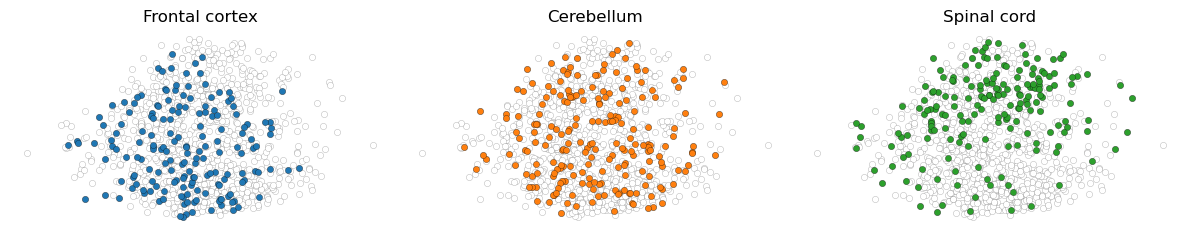

In [20]:
# projection target Visualization on UMAP
pca_coords = adata_pca.obsm['X_pca']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for m, k in enumerate(cate_list[:-1]):
    ax = axes[m]
    # Plot all cells in white
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], 
               color='white', s=20, alpha=1, label='_nolegend_',
               edgecolor='k', linewidth=.1)
    mask = adata_retro.obs['injection_site'] == k
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1], 
               color=col_dict[k], s=20, alpha=1, label=k,
               edgecolor='k', linewidth=.2)
    ax.set_aspect('equal')
    ax.set_title(k.capitalize())
    ax.set_xticks([]);ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.95])
save_figure("injection_site_pca")

## for the original data (no BN) changing the target_sum for library normalizations

# DE analysis 
- we run three methods and find consistently detected genes. 
1. scnapy 
2. scvi 
3. compare scanpy vs scvi
4. pseudobulk with custom t-test
5. pseudobulk with DEseq2
6. putting all together

In [21]:
import transcriptomics_analysis, pseudobulk
n_genes = 10; 
global_LFC_scanpy = 1
global_LFC_scvi = 1
key="rank_genes_groups_filtered"
groups = list(adata_retro_BN.obs['injection_site'].cat.categories)

## (1) scanpy

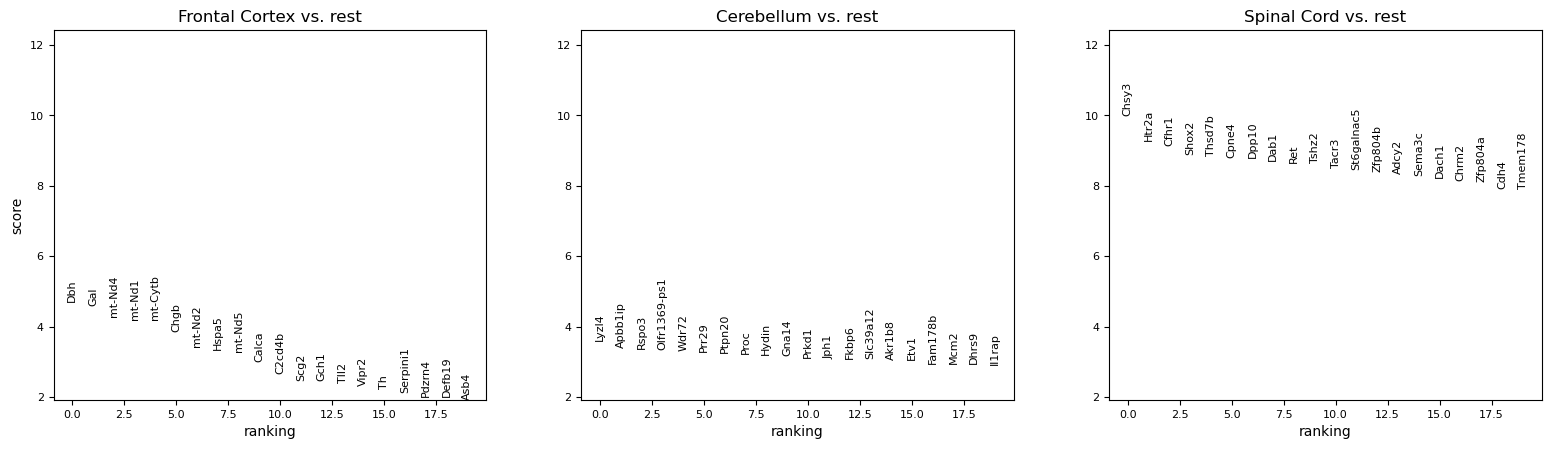

Frontal Cortex 0 []
Cerebellum 0 []
Spinal Cord 6 ['Htr2a', 'Cfhr1', 'Shox2', 'Tshz2', 'Tacr3', 'Zfp804b']


In [22]:
scanpy_genes = transcriptomics_analysis.DE_scanpy(adata_retro_BN, global_LFC_scanpy, n_genes,
                                                  key=key, groups = groups)

## (2) scvi

In [23]:
scvi_genes = transcriptomics_analysis.DE_scvi(adata_retro, model, global_LFC_scvi=1, n_genes=10)

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

## (3) compare scanpy and scvi 

In [24]:
comparison_results={}
for group in scanpy_genes.keys():
    if group in scvi_genes:
        scanpy_set = set(scanpy_genes[group])
        scvi_set = set(scvi_genes[group])
        overlap = scanpy_set.intersection(scvi_set)
        scanpy_only = scanpy_set - scvi_set
        scvi_only = scvi_set - scanpy_set
        comparison_results[group] = {
            'scanpy_genes': scanpy_genes[group],'scvi_genes': scvi_genes[group],
            'overlap': list(overlap),'scanpy_only': list(scanpy_only),'scvi_only': list(scvi_only),
            'overlap_ratio': len(overlap) / len(scanpy_set.union(scvi_set)) if scanpy_set.union(scvi_set) else 0
        }
comparison_results["Cerebellum"].keys()

dict_keys(['scanpy_genes', 'scvi_genes', 'overlap', 'scanpy_only', 'scvi_only', 'overlap_ratio'])

In [25]:
comparison_results["Spinal Cord"]['overlap']

['Zfp804b', 'Tshz2']

## (4) pseudobulk with manual t-test

In [26]:

MOUSE_COL  = "external_donor_name"
TARGET_COL = "injection_site"
groupby_col = 'injection_site'
results = pseudobulk.run_pseudobulk_pipeline(adata=adata_retro,groupby_col=groupby_col,
    mouse_col=MOUSE_COL,use_raw=True,
    agg="sum",
    gene_lengths_dict=gene_lengths,    # same dict you already have
    min_lfc=global_LFC_scanpy,
    max_fdr=None,                      # or e.g. 0.05
    target_order=['Frontal Cortex', 'Cerebellum', 'Spinal Cord'],
    cpm_scale=cpm_scl,
    do_plot=False, # no heatmap since its huge
)

pb_expr          = results["pb_expr"]
pb_meta          = results["pb_meta"]
pb_expr_logcpm   = results["pb_expr_logcpm"]
de_results_pseudobulk       = results["de_df"]
top_genes_dict_pseudobulk   = results["top_genes_dict"]
fig, ax          = results["fig"], results["ax"]

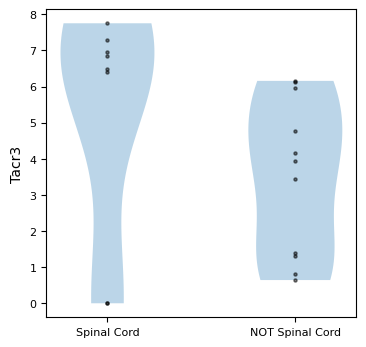

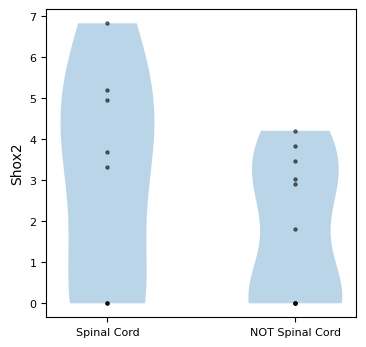

In [27]:
K='Spinal Cord'
for gene in ['Tacr3','Shox2']:
    g1 = pb_expr_logcpm[[K in m for m in pb_expr_logcpm.index]][gene]
    g2 = pb_expr_logcpm[[K not in m for m in pb_expr_logcpm.index]][gene]
    fig, ax = plt.subplots(figsize=(4,4))
    ax.violinplot([g1, g2], showmeans=False, showextrema=False)
    x1 = np.full(len(g1), 1)
    x2 = np.full(len(g2), 2)
    ax.scatter(x1, g1, s=5, alpha=0.5, color='black')
    ax.scatter(x2, g2, s=5, alpha=0.5, color='black')
    ax.set_xticks([1,2])
    ax.set_xticklabels([f"{K}", f"NOT {K}"])
    ax.set_ylabel(gene)

    plt.show()

## (5) pseudobulk with DESeq2 (optional)

In [28]:
target = "Spinal Cord"
deseq_out = pseudobulk.run_deseq2_one_vs_rest(
    pb_expr=pb_expr,
    pb_meta=pb_meta,
    groupby_col=groupby_col,
    target=target,
    n_cpus=4,
    quiet=False,)

cmp = pseudobulk.compare_deseq_vs_ttest(
    deseq_out["res_df"],
    top_genes_dict_pseudobulk,
    target=target,
    lfc_thr=1.0,
    padj_thr=0.05,
)

enriched_spinal = cmp["enriched_df"]
overlap = cmp["overlap"]["overlap"]
only_deseq = cmp["overlap"]["only_a"]
only_ttest = cmp["overlap"]["only_b"]

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.39 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.46 seconds.

Fitting LFCs...
... done in 0.34 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 117 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: injection_site_Spinal_Cord_vs_other Spinal_Cord vs Other
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
A2m            0.635479        4.631261  3.179436  1.456630  0.145219   
AC103362.1     8.400108       -1.867054  0.779647 -2.394743  0.016632   
AC106834.1     8.173692        0.447671  1.074657  0.416571  0.676992   
AC149090.1  5538.722526        0.103668  0.360716  0.287397  0.773809   
AC150683.1  1099.618906        0.633535  0.524039  1.208945  0.226684   
...                 ...             ...       ...       ...       ...   
mt-Cytb     8610.413824        0.296487  0.173650  1.707386  0.087750   
mt-Nd1      9516.823134        0.267938  0.182580  1.467510  0.142237   
mt-Nd2      3206.082016        0.270289  0.176227  1.533760  0.125089   
mt-Nd4      3357.846007        0.240151  0.159336  1.507204  0.131758   
mt-Nd5      4034.014416        0.556914  0.214084  2.601385  0.009285   

                padj  
A2m  

... done in 0.05 seconds.

Running Wald tests...
... done in 0.11 seconds.



In [29]:
len(overlap), len(only_deseq), len(only_ttest)

(30, 43, 4)


## (6) all the overlap

In [30]:
overlap_btw_singlecellmethods = comparison_results["Spinal Cord"]['overlap']
print(len(overlap_btw_singlecellmethods))

finalist_genes =list(set(top_genes_dict_pseudobulk['Spinal Cord']).intersection(overlap_btw_singlecellmethods))

print(finalist_genes, len(finalist_genes))
if len(finalist_genes)==0:
    print('your pseudobulk methods didnt detect any overlaps so ignroing that now.!!! ')
    finalist_genes = overlap_btw_singlecellmethods.copy()
else:  # meaning we have some gnees detected consistently, great
    print('!!!   great finalist   !!!')

2
[] 0
your pseudobulk methods didnt detect any overlaps so ignroing that now.!!! 


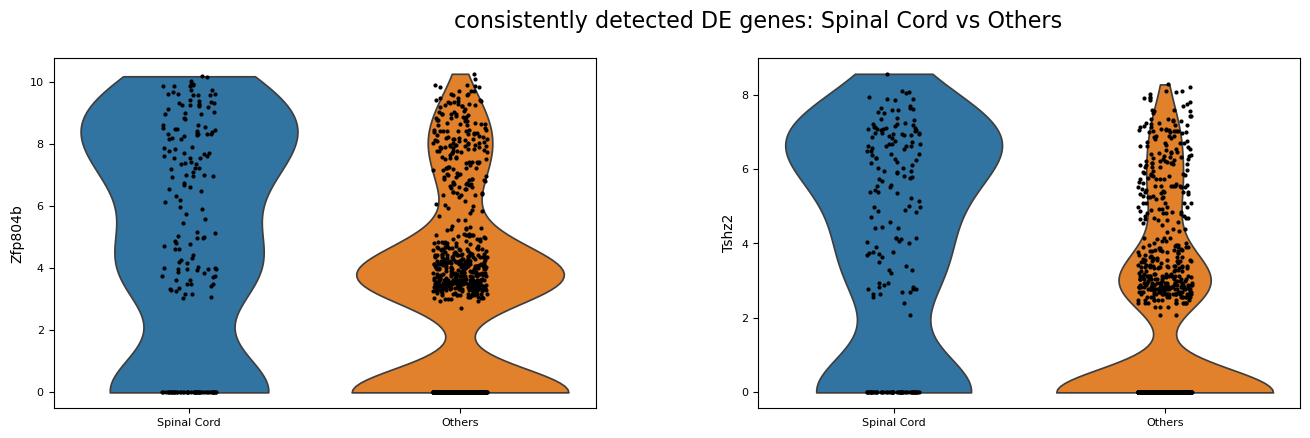

In [31]:
adata_retro.layers["CPM"] = adata_retro.X.copy()
sc.pp.normalize_total(adata_retro, target_sum=1e6, layer="CPM")
adata_retro.layers["log(CPM)"] = adata_retro.layers["CPM"].copy()
sc.pp.log1p(adata_retro, layer="log(CPM)")


spinal_cord_binary = adata_retro.obs['injection_site'].copy()
spinal_cord_binary = spinal_cord_binary.cat.add_categories(['Others'])
spinal_cord_binary[spinal_cord_binary != 'Spinal Cord'] = 'Others'
spinal_cord_binary = spinal_cord_binary.cat.remove_unused_categories()
adata_retro.obs['spinal_cord_binary'] = spinal_cord_binary
sc.pl.violin(adata_retro, keys=finalist_genes, groupby='spinal_cord_binary', size = 3,#log=True,
            rotation=0,show=False, use_raw=False, layer='log(CPM)')
plt.suptitle(f"consistently detected DE genes: Spinal Cord vs Others", fontsize=16)
# save_figure("violin_spincord_DEgenes")
plt.show()


# check these genes distribution in snRNA seq data

In [32]:
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")
adata_sc_orig = sc.read_h5ad(myfilename)
adata_sc_orig.obs['sex'] = adata_sc_orig.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})

adata_sc = anndata.AnnData(1e+6*adata_sc_orig.layers['BN'])
adata_sc.obs = adata_sc_orig.obs.copy()
adata_sc.obsm = adata_sc_orig.obsm.copy()
adata_sc.var = adata_sc_orig.var.copy()

adata_sc.raw=adata_sc.copy()  # its already library normalized 
sc.pp.log1p(adata_sc)
sc.pp.scale(adata_sc, zero_center=True, max_value=10)
sc.tl.pca(adata_sc, n_comps=50, svd_solver='arpack')

adata_sc.obs['spinalcord_enrichedgenes'] = np.sum(adata_sc.raw[:,finalist_genes].X,1)

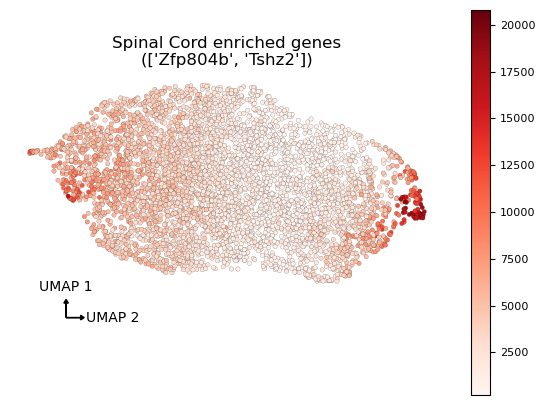

In [33]:
s=10;fs=10
plt.figure(figsize=(7, 5))
ax = plt.gca()
sca = ax.scatter(
    adata_sc.obsm['X_umap'][:, 1],
    adata_sc.obsm['X_umap'][:, 0],
    s=s, c=adata_sc.obs['spinalcord_enrichedgenes'].values, 
    cmap='Reds', edgecolor='k', linewidth=0.1)
plt.colorbar(sca, ax=ax)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Spinal Cord enriched genes\n({finalist_genes})')
ax.set_aspect('equal')

# set the base vector here... 
x0, y0 = np.min(adata_sc.obsm['X_umap'], 0)
ax.arrow(x0, y0, 1, 0, head_width=0.25, head_length=0.2,
         length_includes_head=True, width=0.001, color='black')
ax.arrow(x0, y0, 0, 1, head_width=0.25, head_length=0.2,
         length_includes_head=True, width=0.001, color='black')

ax.text(x0+1.1, y0, 'UMAP 2', va='center', ha='left', fontsize=fs)
ax.text(x0, y0+1.3, 'UMAP 1', va='bottom', ha='center', fontsize=fs)

# save_figure("totalexpression_spincord_DEgenes")
plt.show()

# impute the projection for the snRNAseq data

In [34]:
# just load snRNA data 
adata_sc_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
adata_sc_foo = adata_sc_foo[:,keepgenes]  # this step is really important if you just want to assume teh same order genes!!!
adata_sc_BN = adata_sc_foo.copy()
adata_sc_BN.X = adata_sc_foo.layers['BN'].copy()
adata_sc_BN.raw = adata_sc_BN.copy()

arc_path = TMP_OUT_DIR+'/cellID_pc_0722.csv'
arcinfo = pd.read_csv(arc_path)
arcinfo = arcinfo.set_index('cellID')
adata_sc_BN.obs['pc'] = arcinfo['pseudoclusters'].reindex(adata_sc_BN.obs.index)


In [35]:
(adata_sc_BN.obs.index==adata_sc_foo.obs.index).all()

True

In [36]:
(arcinfo.index == adata_sc_foo.obs.index).all()

True

In [37]:
keepgenes

array(['0610040J01Rik', '1110019D14Rik', '1600002D24Rik', ..., 'mt-Nd2',
       'mt-Nd4', 'mt-Nd5'], dtype='<U16')

In [38]:
import seaborn as sns
order = cate_list[:-1]
palette = dict(zip(order, sns.color_palette('tab10', len(order))))


In [39]:
np.sum(adata_sc_BN.X,1)

array([0.99999976, 1.0000004 , 0.99999994, ..., 0.99999994, 1.0000006 ,
       0.9999996 ], dtype=float32)

In [40]:
use_batchcorrected = False # avoiding any scvi induced artifact. 

adata_sc_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
adata_sc_foo = adata_sc_foo[:,keepgenes]  # this step is really important if you just want

if use_batchcorrected:  ### both batch corrected
    X_sc =adata_sc_BN[:,keepgenes].X  # normalized
#     X_retro = adata_retro.layers['BN'].astype(float)    
    X_retro = adata_retro[:,keepgenes].X.astype(float)  
else:    ### raw!!
    X_sc =adata_sc_foo[:,keepgenes].X  # this is literally raw counts
    X_retro = adata_retro[:,keepgenes].X.astype(float)  #this is length normalized but raw counts (thats why they sum to 1M)

X_sc_norm = processing.rankrows(X_sc,standardize = True)
X_retro_norm = processing.rankrows(X_retro,standardize = True)

k = 10
percentage_thre = .8 #  >= this percentage value will be considered to be valid imputations
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_retro_norm)
distances, indices = nbrs.kneighbors(X_sc_norm) # distance: size (N_snRNA, K)
print(distances.shape, indices.shape) # for each snRNAseq, find k best retroseq cells
allprojections = np.array(adata_retro.obs['injection_site'].values)

imputed_projections = []
disagreement_scores = []
for i in range(X_sc_norm.shape[0]):
    neighbor_idx = indices[i]  # length K
    neighbor_projections = allprojections[neighbor_idx]
    valid_projections = neighbor_projections[~pd.isna(neighbor_projections)]
    
    if len(valid_projections) == 0:
        imputed_projections.append(np.nan)
        disagreement_scores.append(1.0)  # Maximum disagreement
    else:
        unique_targets, counts = np.unique(valid_projections, return_counts=True)
        max_count = np.max(counts)
        max_target = unique_targets[np.argmax(counts)]
        
        if max_count >= int(percentage_thre*len(valid_projections)): # can change this 
            imputed_projections.append(max_target)
        else:
            imputed_projections.append(np.nan)
        
        # Compute disagreement score based on valid neighbors only
        disagreement_score = 1 - (max_count / len(valid_projections)) 
        disagreement_scores.append(disagreement_score)

adata_sc_BN.obs['imputed_projection'] = imputed_projections
adata_sc_BN.obs['disagreement_score'] = disagreement_scores
adata_sc_BN.obs["imputed_projection"] = pd.Categorical(adata_sc_BN.obs["imputed_projection"], # change the color 
                                                       categories=cate_list[:-1],ordered=True)


# also add for the visualization of total expressions of these genes 
adata_sc_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
adata_sc_BN.obs['spinalcord_enrichedgenes'] = np.sum(adata_sc_foo[:,finalist_genes].X,1)  # raw counts sum


(4845, 10) (4845, 10)


Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_umap.svg
Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_umap.png


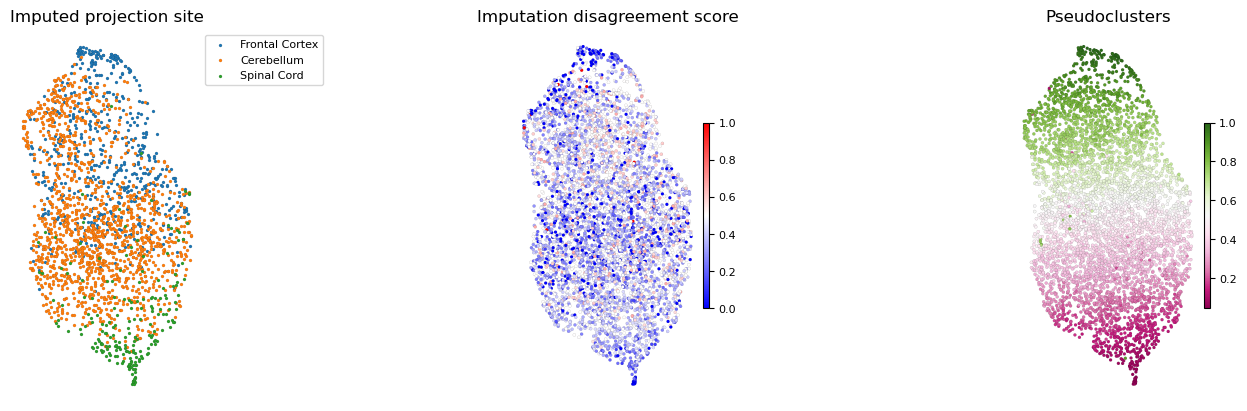

In [41]:
s=5; lw=.05
fig, axes = plt.subplots(1, 3, figsize=(15,4), constrained_layout=True)
ax = axes[0]
for c in cate_list[:-1]:
    ax.scatter(adata_sc_BN.obsm['X_umap'][adata_sc_BN.obs['imputed_projection']==c, 0],
               adata_sc_BN.obsm['X_umap'][adata_sc_BN.obs['imputed_projection']==c, 1],
               s=s, color=palette[c], edgecolor='k', linewidth=lw, label = c)
for spine in ax.spines.values(): spine.set_visible(False)
ax.legend(bbox_to_anchor=(1, 1))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Imputed projection site')
ax.set_aspect('equal')

ax = axes[1]
sca1 = ax.scatter(adata_sc_BN.obsm['X_umap'][:, 0], adata_sc_BN.obsm['X_umap'][:, 1],
                 s=s, c=adata_sc_BN.obs['disagreement_score'].values,
                 cmap='bwr', edgecolor='k', linewidth=lw,vmin = 0,vmax=1)
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Imputation disagreement score')
ax.set_aspect('equal')

ax = axes[2]
sca2 = ax.scatter(adata_sc_BN.obsm['X_umap'][:, 0], adata_sc_BN.obsm['X_umap'][:, 1],
           s=s, c=adata_sc_BN.obs['pc'].values,
           cmap='PiYG', edgecolor='k', linewidth=lw)
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Pseudoclusters')
ax.set_aspect('equal')
cax = axes[1].inset_axes([1.02, 0.25, 0.03, 0.5])  # [x0,y0,w,h] in axes coords
fig.colorbar(sca1, cax=cax)
cax = axes[2].inset_axes([1.02, 0.25, 0.03, 0.5])  # [x0,y0,w,h] in axes coords
fig.colorbar(sca2, cax=cax)
save_figure('projection_imputation_results_umap')
plt.show()

Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_violin.svg
Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_violin.png


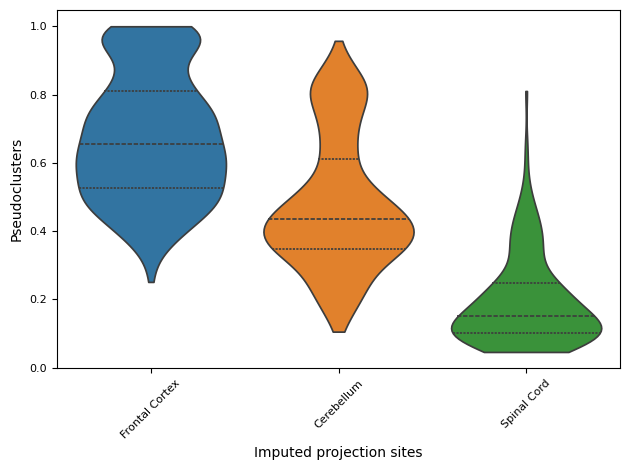

Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_hist.svg
Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_hist.png


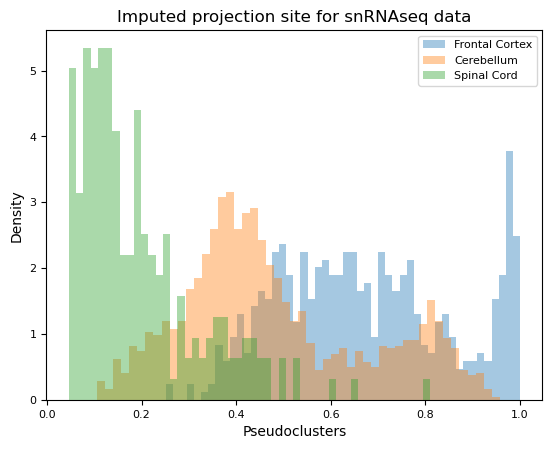

In [42]:
import seaborn as sns
order = cate_list[:-1]
palette = dict(zip(order, sns.color_palette('tab10', len(order))))

sns.violinplot(
    data=adata_sc_BN.obs,
    x='imputed_projection',
    y='pc',
    order=order,
    palette=palette,
    cut=0,
    inner='quartile'
)
plt.xticks(rotation=45)
plt.xlabel('Imputed projection sites')
plt.ylabel('Pseudoclusters')
plt.tight_layout()
save_figure('projection_imputation_results_violin')
plt.show()

for c in cate_list[:-1]:
    plt.hist(adata_sc_BN.obs.loc[adata_sc_BN.obs['imputed_projection'] == c, 'pc'],
             bins=50, alpha=0.4, density=True, label=c, color=palette[c])
plt.legend()
plt.xlabel('Pseudoclusters');plt.ylabel('Density')
plt.title('Imputed projection site for snRNAseq data')
save_figure('projection_imputation_results_hist')
plt.show()


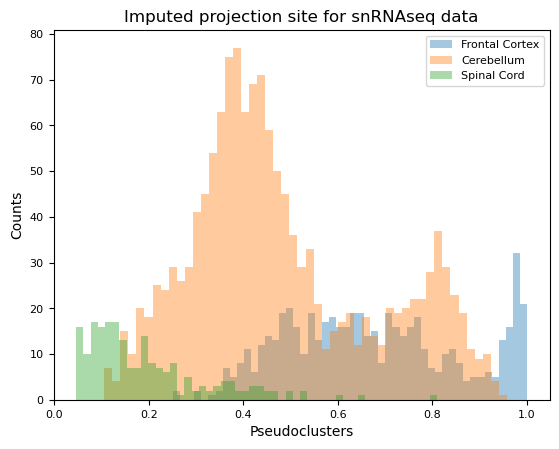

In [43]:

for c in cate_list[:-1]:
    plt.hist(adata_sc_BN.obs.loc[adata_sc_BN.obs['imputed_projection'] == c, 'pc'],
             bins=50, alpha=0.4, density=False, label=c, color=palette[c])
plt.legend()
plt.xlabel('Pseudoclusters');plt.ylabel('Counts')
plt.title('Imputed projection site for snRNAseq data')
plt.show()


Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_scatter.svg
Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_scatter.png


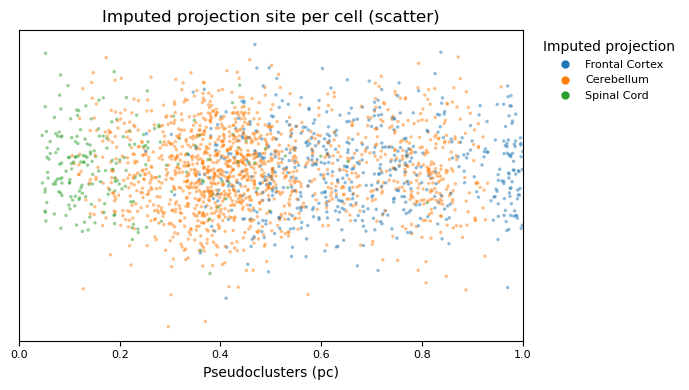

In [44]:
import seaborn as sns

df = adata_sc_BN.obs.copy()

# categories + colors (reuse your existing order/palette)
order = cate_list[:-1]
palette = dict(zip(order, sns.color_palette('tab10', len(order))))

# ensure column types are right
df = df[df["imputed_projection"].isin(order)].copy()
df["imputed_projection"] = pd.Categorical(df["imputed_projection"], categories=order, ordered=True)

# ---------- Scatter (each dot = one cell) ----------
plt.figure(figsize=(7, 4))

# vertical jitter; keep small so it reads as a 1D distribution
rng = np.random.default_rng(0)
y_jitter = rng.normal(loc=0.0, scale=0.015, size=df.shape[0])

plt.scatter(
    df["pc"].to_numpy(),
    y_jitter,
    c=[palette[c] for c in df["imputed_projection"]],
    s=6,
    alpha=0.5,
    linewidths=0
)

plt.xlim(0, 1)  # set if pc is in [0,1]
plt.yticks([])
plt.xlabel("Pseudoclusters (pc)")
plt.ylabel("")
plt.title("Imputed projection site per cell (scatter)")
# legend
handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=6,
                      markerfacecolor=palette[c], markeredgecolor='none', label=c)
           for c in order]
plt.legend(handles=handles, title="Imputed projection", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_figure("projection_imputation_results_scatter")
plt.show()

Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_hist_scatter.svg
Saving figure to: /root/capsule/output/figures/retroseq/projection_imputation_results_hist_scatter.png


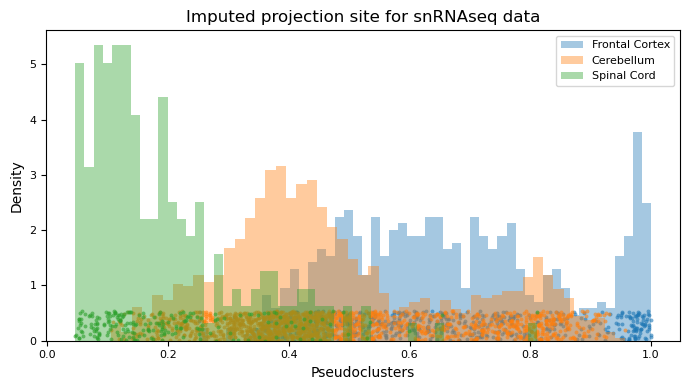

In [45]:

df = adata_sc_BN.obs
order = cate_list[:-1]

# ---- First pass: compute max density for scaling ----
max_density = 0
hist_data = {}

for c in order:
    x = df.loc[df['imputed_projection'] == c, 'pc'].to_numpy()
    hist, bin_edges = np.histogram(x, bins=50, density=True)
    max_density = max(max_density, hist.max())
    hist_data[c] = x

# ---- Plot histogram + scatter ----
plt.figure(figsize=(7, 4))

for c in order:
    x = hist_data[c]

    # histogram
    plt.hist(
        x,
        bins=50,
        alpha=0.4,
        density=True,
        color=palette[c],
        label=c
    )

    # scatter with stronger vertical jitter
    rng = np.random.default_rng(0)
    y_jitter = rng.uniform(
        0,
        max_density * 0.1,   # increase this (e.g. 0.3–0.4) if you want even more spread
        size=len(x)
    )

    plt.scatter(
        x,
        y_jitter,
        color=palette[c],
        s=8,
        alpha=0.6,
        linewidths=0
    )

plt.legend()
plt.xlabel('Pseudoclusters')
plt.ylabel('Density')
plt.title('Imputed projection site for snRNAseq data')

plt.tight_layout()
save_figure('projection_imputation_results_hist_scatter')
plt.show()

# some sort of statistical test
- ANOVA has normal residual assumptions. 
- (GPT suggested) rank-based analogue of ANOVA: kruskal-wallis (good for skewed and bounded distributions..)

In [47]:
from scipy.stats import kruskal
order = cate_list[:-1]
# collect score vectors in the same order as the plot
groups = [
    adata_sc_BN.obs.loc[adata_sc_BN.obs['imputed_projection'] == c, 'pc'].dropna().values
    for c in order
]

# overall Kruskal–Wallis test
H, p = kruskal(*groups)

print(f"Kruskal-Wallis H = {H:.4f}")
print(f"P-value = {p:.3e}")

Kruskal-Wallis H = 717.5269
P-value = 1.552e-156


In [8]:
print("Analysis complete! All visualizations have been saved to:", fig_path)

Analysis complete! All visualizations have been saved to: /results/figures/retroseq
